Here we see from a more theoretical perspective, that the boundary points indeed are the ones most sensitive to tiny perturbations in the input.
The results align with M1, as the rounding differences in the two precisions essentially acts as small perturbations. So these results are a nice proxy of results seen in M1.

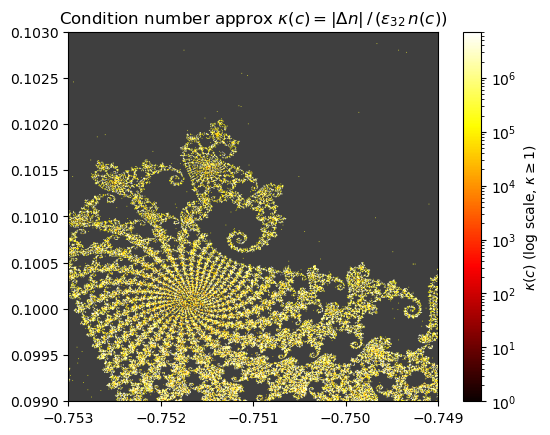

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000
x = np.linspace(-0.7510, -0.7460, N)
y = np.linspace( 0.0990,  0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)

eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

def escape_count(C, max_iter):
    z = np.zeros_like(C)
    cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)
    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k
        esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)

cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa.T, cmap=cmap_k, origin='upper',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

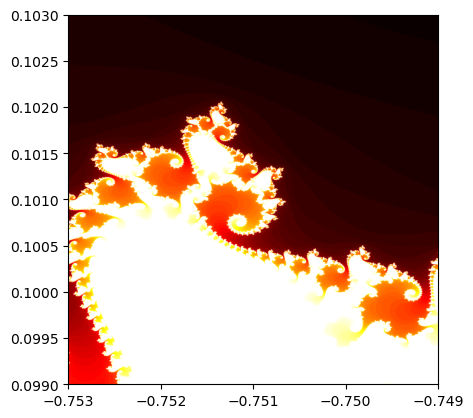

In [4]:
from numba import njit, complex64, prange
import numpy as np

@njit(parallel=True, fastmath=True)
def generate_set(resolution:int = 4000):
    x_region = np.linspace(-0.7510, -0.7460, resolution).astype(np.float32)
    y_region = np.linspace(0.0990,  0.1030, resolution).astype(np.float32)
    grid = np.zeros((resolution, resolution), dtype=np.float32)
    for i in prange(0, resolution):
        for j in range(0, resolution):
            c = complex64(x_region[i] + 1j*y_region[j])
            z = complex64(0j)
            for k in range(0, 100):
                z = z**2 + c
                if z.real*z.real + z.imag*z.imag > 4.0: 
                    n = k
                    break
                else: n = 100
            grid[i][j] = n
    return grid

grid = generate_set()
plt.imshow(grid, cmap=cmap_k, origin='upper', extent=[-0.7530, -0.7490, 0.0990, 0.1030])